In [38]:
from langgraph.graph import StateGraph, START, END
from langchain_google_genai import GoogleGenerativeAI
from typing import TypedDict
from dotenv import load_dotenv

In [39]:
load_dotenv()

True

In [40]:
model = GoogleGenerativeAI(model="gemini-2.5-flash", temperature=0.7)

In [41]:
class BatsmanState(TypedDict):
    runs: int
    balls: int
    fours: int
    sixes: int

    sr: float
    bpb: float
    boundary_pr: float
    summary: str

In [42]:
def calculate_sr(state: BatsmanState):
    sr = (state['runs']/state['balls']) * 100

    return {'sr': sr}

In [43]:
def calculate_bpb(state: BatsmanState):
    bpb = state['balls'] / (state['fours'] + state['sixes'])

    return {'bpb': bpb}

In [44]:
def calculate_boudary_pr(state: BatsmanState):
    boudary_pr = (((state['fours'] * 4) + state['sixes'] * 6) / state['runs']) * 100

    return {'boundary_pr': boudary_pr}

In [50]:
def generate_summary(state: BatsmanState) -> BatsmanState:
    summary = f"""
Batsman details:\n
Strike Rate: {state['sr']}\n
Balls per Boundary: {state['bpb']}\n
Boundary Percentage: {state['boundary_pr']}
"""

    return {'summary': summary}

In [53]:
graph = StateGraph(BatsmanState)

graph.add_node("calculate_sr", calculate_sr)
graph.add_node("calculate_bpb", calculate_bpb)
graph.add_node("calculate_boundary_pr", calculate_boudary_pr)
graph.add_node("generate_summary", generate_summary)

graph.add_edge(START, "calculate_sr")
graph.add_edge(START, "calculate_bpb")
graph.add_edge(START, "calculate_boundary_pr")

graph.add_edge("calculate_sr", "generate_summary")
graph.add_edge("calculate_bpb", "generate_summary")
graph.add_edge("calculate_boundary_pr", "generate_summary")

graph.add_edge("generate_summary", END)

workflow = graph.compile()

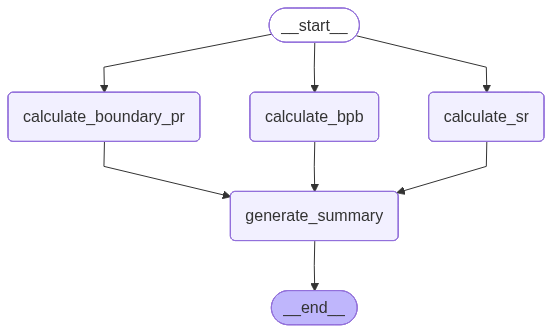

In [47]:
workflow

In [56]:
initial_state = { 'runs': 100, 'balls': 50, 'fours': 6, 'sixes': 4 }

final_state = workflow.invoke(initial_state)

In [57]:
print(final_state['summary'])


Batsman details:

Strike Rate: 200.0

Balls per Boundary: 5.0

Boundary Percentage: 48.0

